<a href="https://colab.research.google.com/github/enm0910/ST554/blob/main/EMartinez_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####Author: Emma Martinez
####Course: ST 554 HW#5
####Purpose: Homework 5- Simulation of a sampling distribution, big data examples & rare events, and querying a database

#Part 1- Concepts

###Question #1

The Five V's of Big Data include volume, velocity, variety, veracity, and value. An example of big data I'm interested in is bird migration tracking, particularly through platforms like eBird. I am an avid birder and use the app frequently. The Five V's are applicable as follows:

**Volume**: Millions of data points are generated every migration season. Projects like eBird, which is run by Cornell Lab of Ornithology, have collected over 1 billion bird observation records from the public worldwide. Additionally, they also factor in radar data, GPS tags, and weather station data, which makes for a truly massive dataset.

**Velocity**: During peak migration seasons, spring and fall, data comes in extremely fast. Weather radar detects billions of birds moving overnight in real time, and eBird users are generating thousands of sighting submissions per day. The data needs to be processed quickly to be useful for things like issuing migration alerts.

**Variety**: Bird migration data comes in many different forms- GPS tracking tags on individual birds, sighting reports from the public (text + location), Doppler radar imagery, satellite images, audio recordings of bird calls, and weather data. These are very different data types that have to be combined.

**Veracity**: The eBird user's data varies wildly in quality- an expert birder's report is much more reliable than a beginner's. There's also geographic bias (more observations near cities and trails), seasonal bias (more people go birding on nice days), and identification errors. Not all observations can be fully trusted.

**Value**: Understanding migration patterns helps with conservation (identifying critical stopover habitats), predicting and preventing bird-aircraft collisions, studying the effects of climate change on migration timing, and managing endangered species. The insights have genuinely significant repercussions.

###Question #2

The CRUD acronym stands for create, read, update, and delete. In the context of the Lahman baseball database, the acronym could represent:

**C**: Add new data = INSERT a player's record if a new one joins the team

**R**: Retrieve/look at data = SELECT players from a team to look at specific players only

**U**: Modify existing data = UPDATE a player's salary if they get a raise

**D**: Remove data = DELETE a game record if it is found to be incorrect

###Question # 3

The HAVING clause filters results after a GROUP BY query based on aggregate functions. This is helpful because it filters groups after the aggregation has been performed, rather than before (like WHERE clause).

#Part 2- Simulation of a Sampling Distribution

###Question #4

In [ ]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn.linear_model import LinearRegression

# Set a random seed so results are reproducible
rng = default_rng(32)

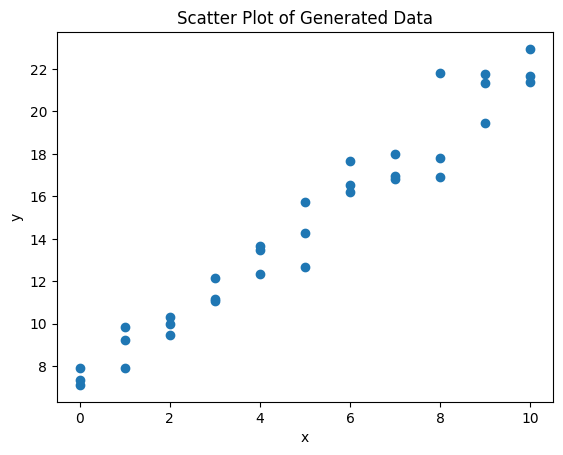

In [ ]:
# Generate initial data + visualize it

beta_0 = 7
beta_1 = 1.5

# Create x values: 0 to 10 in steps of 1 repeated 3 times
x = np.array(list(np.linspace(start=0, stop=10, num=11)) * 3)
n = 33

# Generate y values: the true line + random noise
y = beta_0 + beta_1 * x + rng.standard_normal(n)

# Plot the data
plt.scatter(x=x, y=y)
plt.title('Scatter Plot of Generated Data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [ ]:
# Run simulation 5000 times and save slopes

# This list will store 5000 estimated slopes
slopes = []

# Reshape x for sklearn (2D array)
x_reshaped = x.reshape(-1, 1)

# Repeat 5000 times
for i in range(5000):
    # Generate new random y values each time
    y_sim = beta_0 + beta_1 * x + rng.standard_normal(n)

    # Fit a linear regression model
    model = LinearRegression()
    model.fit(x_reshaped, y_sim)

    # Save the estimated slope
    slopes.append(model.coef_[0])

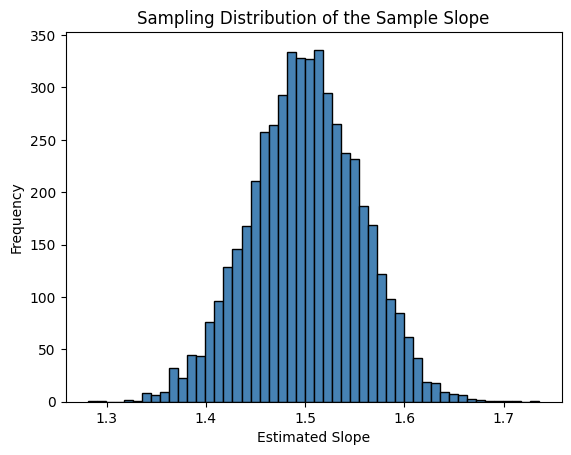

In [ ]:
# Create histogram of slopes

plt.hist(slopes, bins=50, edgecolor='black', color='steelblue')
plt.title('Sampling Distribution of the Sample Slope')
plt.xlabel('Estimated Slope')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Approximate probability of slope >1.65

# Convert list to numpy array for calculation
slopes_array = np.array(slopes)

# Count how many slopes are greater than 1.65
prob = np.mean(slopes_array > 1.65)

print(f'Approximate probability of slope > 1.65: {prob:.4f}')

# Interpretation + why this value is important: This probability tells us if the
# true slope were 1.5, how often we would randomly observe a slope as large as
# 1.65 just by chance. This is essentially the p-value. A small probability
# indicates that observing slope > or = 1.65 would be unusual, which also
# connects to hypothesis testing; we might reject H0 if probability is small enough.

Approximate probability of slope > 1.65: 0.0038


#Part 3- Big Data Examples + Rare Events

###Question #5

In the linked article, the author discusses a case where Amazon's hiring algorithm penalized resumes with the word "women" in them. This is an example of implicit/gender-bias since this problematic algorithm had no real basis to penalize these resumes other than prejudices borne from training on data containing implicit biases against women. To remedy this, the algorithm should be trained on more diverse and balanced data and gender-identifying terms should be removed from the input so the model cannot learn to associate them with resume eligiblity.

###Question #6

In this article, the field of oceanography has a multitude of uses for big data. New technologies called Argo floats are surface and underwater autonomous vehicles that gather and transmit data to provide a 3D view of previously data-poor regions. Additionally, 3D modeling and mapping provide valuable insights of the ocean floor, ocean currents, transfer of heat, nutrients, etc. Overall, these tools are integral to managing oil spill cleanup, ship traffic, seismology readings, and more.
Since Argo floats and ocean sensors are not evenly spread across the ocean and are typically clustered along shorelines and ship routes, the resulting data can appear to underrepresent other areas of the ocean. This could affect, for example, an oil spill prediction model if there are huge sensor gaps in the middle of the open water.

###Question #7

An understanding of rare events is helpful in natural disaster management- for instance, in the 27 years I've lived in Austin, Texas we haven't had a detrimental tornado pass through town. However, if an F5 tornado ever happened, it would be helpful to have the relevant data on hand for things like evacuation planning, emergency resource allocation, early warning systems, etc.

#Part 4- Querying a Database

###Question #8

In [ ]:
# Connect to database and review tables
import sqlite3
import pandas as pd

conn = sqlite3.connect('lahman_1871-2022.sqlite')
print('Connected to database!')

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

Connected to database!
                   name
0           AllstarFull
1           Appearances
2        AwardsManagers
3         AwardsPlayers
4   AwardsShareManagers
5    AwardsSharePlayers
6               Batting
7           BattingPost
8        CollegePlaying
9              Fielding
10           FieldingOF
11      FieldingOFsplit
12         FieldingPost
13           HallOfFame
14            HomeGames
15             Managers
16         ManagersHalf
17                Parks
18               People
19             Pitching
20         PitchingPost
21             Salaries
22              Schools
23           SeriesPost
24                Teams
25      TeamsFranchises
26            TeamsHalf


###Question #9

In [ ]:
# Return teams from 2015
teams_2015 = pd.read_sql("SELECT * FROM Teams WHERE yearID = 2015", conn)
print(teams_2015)
print(f'Number of teams: {len(teams_2015)}')

    yearID lgID teamID franchID divID  Rank    G  Ghome    W   L  ...   DP  \
0     2015   AL    BAL      BAL     E     3  162     78   81  81  ...  134   
1     2015   AL    BOS      BOS     E     5  162     81   78  84  ...  148   
2     2015   AL    CHA      CHW     C     4  162     81   76  86  ...  159   
3     2015   AL    CLE      CLE     C     3  161     80   81  80  ...  136   
4     2015   AL    DET      DET     C     5  161     81   74  87  ...  165   
5     2015   AL    HOU      HOU     W     2  162     81   86  76  ...  131   
6     2015   AL    KCA      KCR     C     1  162     81   95  67  ...  138   
7     2015   AL    LAA      ANA     W     3  162     81   85  77  ...  108   
8     2015   AL    MIN      MIN     C     2  162     81   83  79  ...  150   
9     2015   AL    NYA      NYY     E     2  162     81   87  75  ...  135   
10    2015   AL    OAK      OAK     W     5  162     81   68  94  ...  154   
11    2015   AL    SEA      SEA     W     4  162     81   76  86

###Question #10

In [ ]:
# Return Hall of Fame players with corresponding year and category
hof = pd.read_sql(
    """
    SELECT playerID, yearid, category
    FROM HallOfFame
    WHERE inducted = 'Y'
    """,
    conn
)
print(hof)

      playerID  yearid           category
0    aaronha01    1982             Player
1    alexape01    1938             Player
2    alomaro01    2011             Player
3    alstowa01    1983            Manager
4    andersp01    2000            Manager
..         ...     ...                ...
335  yastrca01    1989             Player
336  yawketo99    1980  Pioneer/Executive
337  youngcy01    1937             Player
338  youngro01    1972             Player
339  yountro01    1999             Player

[340 rows x 3 columns]


###Question #11

In [ ]:
# Return unique managers of Pirates team
pit_managers = pd.read_sql(
    """
    SELECT DISTINCT playerID
    FROM Managers
    WHERE teamID = 'PIT'
    """,
    conn
)
print(pit_managers)
print(f'Total unique managers: {len(pit_managers)}')


     playerID
0   bezdehu99
1   bragabo01
2   buckeal99
3   burnsto01
4   burwebi01
5    bushdo01
6   callani01
7   clarkfr01
8   davissp01
9   donovpa01
10  dunlafr01
11    ensje01
12  friscfr01
13  gibsoge01
14  grammal01
15  haneyfr01
16  hanlone01
17  heckegu01
18  hermabi01
19  hurdlcl01
20  lamonge01
21  leylaji99
22  mackape01
23   mackco01
24  mcclell01
25  mcgunbi01
26  mckecbi01
27  meyerbi01
28  murtada01
29  phillho99
30  princto01
31  russejo02
32  sheltde99
33  shepala99
34  tannech01
35  tracyji01
36  traynpi01
37  virdobi01
38  wagneho01
39  walkeha01
40  watkibi01
Total unique managers: 41


###Question #12

In [ ]:
# Return all playerIDs for the people that managed for a team that were inducted
# into the hall of fame + programmatically report
manager_hof = pd.read_sql(
    """
    SELECT DISTINCT m.playerID
    FROM Managers m
    WHERE m.playerID IN (
        SELECT playerID
        FROM HallOfFame
        WHERE inducted = 'Y'
    )
    """,
    conn
)
print(manager_hof)
print(f'Number of managers inducted into the Hall of Fame: {len(manager_hof)}')

     playerID
0   alstowa01
1   andersp01
2   ansonca01
3   applilu01
4   baineha01
..        ...
92  willidi02
93  willite01
94  wrighge01
95  wrighha01
96  youngcy01

[97 rows x 1 columns]
Number of managers inducted into the Hall of Fame: 97


###Question #13

In [ ]:
# Hall of fame managers' win/loss records
hof_manager_seasons = pd.read_sql(
    """
    SELECT m.playerID, m.G, m.W, m.L
    FROM Managers m
    INNER JOIN HallOfFame h ON m.playerID = h.playerID
    WHERE h.inducted = 'Y'
    """,
    conn
)

# Group by playerID and sum up wins and losses
wl_records = hof_manager_seasons.groupby('playerID').agg(
    Total_W=('W', 'sum'),
    Total_L=('L', 'sum')
).reset_index()

# Create win/loss percentage column
wl_records['WL_Pct'] = wl_records['Total_W'] / (wl_records['Total_W'] + wl_records['Total_L'])

# Sort from highest to lowest win percentage
wl_records = wl_records.sort_values('WL_Pct', ascending=False)

print(wl_records)

     playerID  Total_W  Total_L    WL_Pct
75  simmote01        1        0  1.000000
94  wrighge01       59       25  0.702381
78  spaldal01       78       47  0.624000
57  mccarjo99     2125     1333  0.614517
19  comisch01      840      541  0.608255
..        ...      ...      ...       ...
8   bottoji01       21       56  0.272727
3   applilu01       10       30  0.250000
4   baineha01        1        3  0.250000
86  wagneho01        1        4  0.200000
20  connoro01        8       37  0.177778

[97 rows x 4 columns]
